In [1]:
from pathlib import Path
import sys
import math

planning_path = Path('.').absolute().parents[0] / 'cloud_auto_park'
print(planning_path)

sys.path.append(str(planning_path))

from trajectory_utils import *
import numpy as np
import time


/project/project/sim_ws/src/digital_twin/cloud_auto_park/cloud_auto_park


In [2]:
def setup_planning_scenario(gap_dist, x_sep, y_sep, is_left, is_wall):
    
    obstacle_sep = gap_dist
    sign = 1 if is_left else -1
    obb_1 = OrientedBoundingBox(-x_sep, sign * y_sep, 4.0, 2.0, math.pi/2)
    obb_2 = OrientedBoundingBox(-x_sep - obstacle_sep, sign * y_sep, 4.0, 2.0, math.pi/2)
    wall = OrientedBoundingBox(-5.0, -sign * 2.5, 12.0, 1.0, 0.0)
    
    obstacles = [obb_1, obb_2]
    if is_wall: obstacles.append(wall)
    
    desired_pose = OrientedBoundingBox(-x_sep - (obstacle_sep / 2.0), sign * y_sep, 4.0, 2.0, -sign * math.pi/2)
    
    return desired_pose, obstacles


In [3]:
fig_save_path = 'figures/doe/'

def run_metrics(traj, obstacles):
    
    min_separation = math.inf
    # for each obstacle, get closest distance between ego following trajectory and the obstacle
    for idx, obstacle_obb in enumerate(obstacles):
        min_separation = get_min_separation_between_traj_and_obs(traj, obstacle_obb)
        
    max_abs_curv = np.max(np.abs(traj.curvatures))
    
    return {'min_separation': min_separation, 'max_abs_curv': max_abs_curv}

def run_planning_scenario(desired_pose, obstacles, metadata):
    
    metrics = {}
    
    # run optimizer to get trajectory
    traj_optimizer = TrajectoryOptimizer(method='BFGS', speed_mps=1.0, sample_rate_hz=50, reverse=True)
    
    # profile traj generation time
    start_time = time.process_time()
    traj_optimizer.generate_optimal_trajectory(desired_pose, obstacles)
    elapsed_time = time.process_time() - start_time
    metrics['solve_time'] = elapsed_time
    metrics['traj'] = traj_optimizer.optimized_traj
    
    # construct filename from metadata
    dir_string = 'left' if metadata['is_left'] else 'right'
    wall_string = 'wall' if metadata['is_wall'] else 'nowall'
    filename_prefix = f"planner_gap_{metadata['gap_dist']:.2f}_xsep_{metadata['x_sep']:.2f}_ysep_{metadata['y_sep']:.2f}_{dir_string}_{wall_string}"
    filename_prefix = filename_prefix.replace('.', '-')
    
    # get metrics, plot and save initial trajectory
    metrics['initial'] = run_metrics(traj_optimizer.initial_traj, obstacles)
    fig, ax = plot_desired_path(traj_optimizer.initial_traj, obstacles, num_intermediate_ego=50)
    ax.set_title('Initial Trajectory')
    fig.savefig(fig_save_path + filename_prefix + '_init.svg')
    
    # get metrics, plot and save final trajectory
    metrics['final'] = run_metrics(traj_optimizer.optimized_traj, obstacles)
    fig, ax = plot_desired_path(traj_optimizer.optimized_traj, obstacles, num_intermediate_ego=50)
    ax.set_title('Optimized Trajectory')
    fig.savefig(fig_save_path + filename_prefix + '_opt.svg')
    
    return metrics

def construct_and_run_scenario(metadata):
    
    desired_pose, obstacles = setup_planning_scenario(**metadata)
    metrics = run_planning_scenario(desired_pose, obstacles, metadata)
    return metrics


In [ ]:
import itertools

gap_dists = [4.5, 5.0, 5.5, 6.0, 6.5, 7.0]
x_seps = [1.0, 2.0, 3.0, 4.0]
y_seps = [3.5, 4.0, 4.5, 5.0]
walls = [True, False]
directions = [True, False]
combinations = list(itertools.product(gap_dists, x_seps, y_seps, walls, directions))
print(len(combinations))

# setup all combinations for doe
scenarios = []
for combo in combinations:
    metadata = {
        'gap_dist': combo[0], 
        'x_sep': combo[1], 
        'y_sep': combo[2], 
        'is_left': combo[3], 
        'is_wall': combo[4]    
    }
    scenarios.append(metadata)
    break


384


In [5]:
import multiprocessing as mp

results = {}

# Determine your system's core count
cores = mp.cpu_count()

with mp.Pool(processes=cores) as pool:
    results = pool.map(construct_and_run_scenario, scenarios)


/project/project/sim_ws/src/digital_twin/cloud_auto_park/cloud_auto_park/trajectory_utils.py:267: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1)
/project/project/sim_ws/src/digital_twin/cloud_auto_park/cloud_auto_park/trajectory_utils.py:267: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1)
/project/project/sim_ws/src/digital_twin/cloud_auto_park/cloud_auto_park/trajectory_utils.py:267: RuntimeWarning: More tha

In [6]:
import pandas as pd

gap_dists = []
x_seps = []
y_seps = []
walls = []
directions = []
optimized = []
solve_times = []
min_sep = []
max_abs_curv = []
trajs = []

for i in range(len(results)):
    gap_dists.append(scenarios[i]['gap_dist'])
    gap_dists.append(scenarios[i]['gap_dist'])
    x_seps.append(scenarios[i]['x_sep'])
    x_seps.append(scenarios[i]['x_sep'])
    y_seps.append(scenarios[i]['y_sep'])
    y_seps.append(scenarios[i]['y_sep'])
    walls.append(scenarios[i]['is_wall'])
    walls.append(scenarios[i]['is_wall'])
    directions.append(scenarios[i]['is_left'])
    directions.append(scenarios[i]['is_left'])
    optimized.append(False)
    optimized.append(True)
    solve_times.append(None)
    solve_times.append(results[i]['solve_time'])
    min_sep.append(results[i]['initial']['min_separation'])
    min_sep.append(results[i]['final']['min_separation'])
    max_abs_curv.append(results[i]['initial']['max_abs_curv'])
    max_abs_curv.append(results[i]['final']['max_abs_curv'])
    trajs.append(results[i]['traj'])

results_df = pd.DataFrame(
    dict(zip(
        ['gap_dist', 'x_sep', 'y_sep', 'is_wall', 'is_left', 'is_optimized', 'solve_time', 'min_sep', 'max_abs_curv'],
        [gap_dists, x_seps, y_seps, walls, directions, optimized, solve_times, min_sep, max_abs_curv]
    ))
)


In [7]:
import pickle

# save dataframe for future analysis
with open(f'data/results.pkl', 'wb') as f:
    pickle.dump(results_df, f)

# save trajectories for future analysis
with open(f'data/trajectories.pkl', 'wb') as f:
    pickle.dump(trajs, f)


NameError: name 'results_df_feas_opt' is not defined

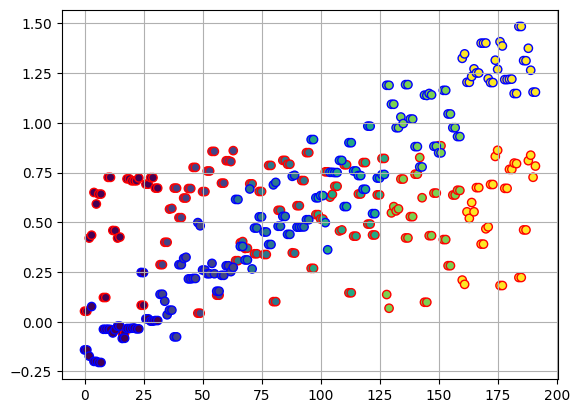

In [8]:
results_df_feas_opt_wall = results_df[(results_df['gap_dist'] > 4) & (results_df['is_optimized']) & (results_df['is_wall'])]
results_df_feas_opt_nowall = results_df[(results_df['gap_dist'] > 4) & (results_df['is_optimized']) & (~results_df['is_wall'])]

plt.scatter(list(range(len(results_df_feas_opt_wall))), results_df_feas_opt_wall['min_sep'], c=results_df_feas_opt_wall['gap_dist'], marker='o', edgecolor='red')
plt.scatter(list(range(len(results_df_feas_opt_nowall))), results_df_feas_opt_nowall['min_sep'], c=results_df_feas_opt_nowall['gap_dist'], marker='o', edgecolor='blue')
plt.grid()
print(np.mean(results_df_feas_opt['min_sep']))


0.6790376367352665


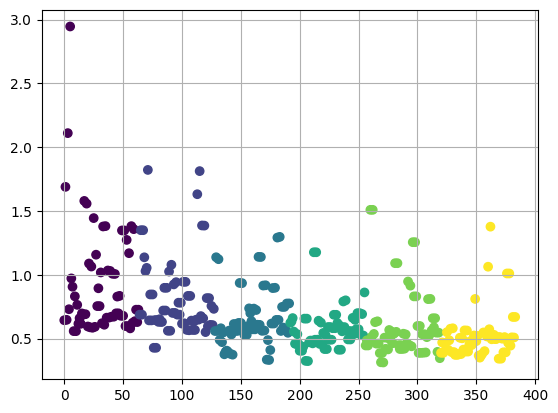

In [ ]:
plt.scatter(list(range(len(results_df_feas_opt))), results_df_feas_opt['max_abs_curv'], c=results_df_feas_opt['gap_dist'])
plt.grid()
print(np.mean(results_df_feas_opt['max_abs_curv']))


9.16123285896875


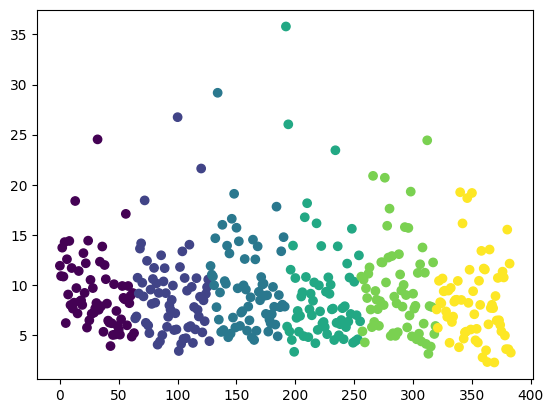

In [ ]:
results_df_feas_opt.sort_values(by='solve_time')

plt.scatter(list(range(len(results_df_feas_opt))), results_df_feas_opt['solve_time'], c=results_df_feas_opt['gap_dist'])
print(np.mean(results_df_feas_opt['solve_time']))
